In [1]:
import sys
import os
import pandas as pd
#Ensure Python can find the Code directory
sys.path.append(os.path.abspath(".."))

import utils

In [2]:
#Use functions and packages
df = utils.load_data()
df.head()

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [8]:
df.groupby('derived_race')['was_approved'].mean().reset_index(name='approval_rate')

,derived_race,approval_rate
0,2 or more minority races,0.659259
1,American Indian or Alaska Native,0.622003
2,Asian,0.707705
3,Black or African American,0.604155
4,Free Form Text Only,0.800000
5,Joint,0.744129
6,Native Hawaiian or Other Pacific Islander,0.566372
7,Race Not Available,0.405725
8,White,0.756063


/var/folders/mj/_5nwhhkd5cjbp6mcqnk7hh540000gn/T/ipykernel_87830/401078786.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=approval_summary, y='derived_race', x='approval_rate', palette='pastel')


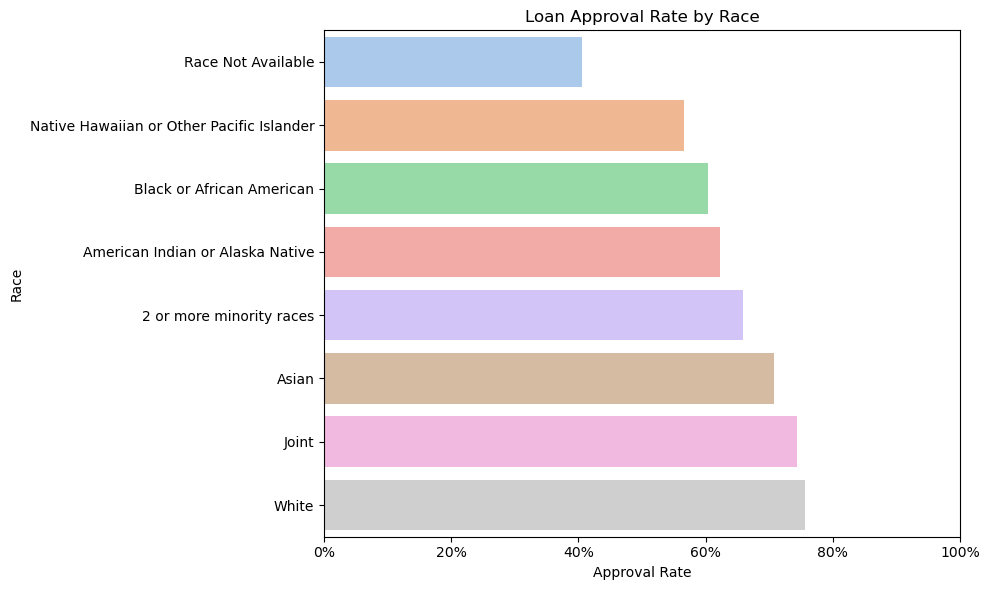

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df[df['derived_race'] != 'Free Form Text Only']

# calculate and sort approval rates
approval_summary = df_filtered.groupby('derived_race')['was_approved'].mean().reset_index(name='approval_rate')

approval_summary = approval_summary.sort_values(by='approval_rate', ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(data=approval_summary, y='derived_race', x='approval_rate', palette='pastel')

plt.title('Loan Approval Rate by Race')
plt.ylabel('Race')
plt.xlabel('Approval Rate')
plt.xlim(0,1)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.tight_layout()
plt.show()